In [127]:
import sys
sys.path.insert(0, '..')

In [128]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from fisher import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [129]:
extra_bad = None
#extra_bad = np.isnan(np.zeros((64, 64)).at[35,60].set(np.nan))

#extra_bad = np.isnan(np.zeros((wid,wid))).at[wid//2-3:wid//2+3,:].set(np.nan)


In [130]:
np.load("spectrum_basis.npy").shape

(100, 100)

In [131]:
def load_spectrum_basis(file, nwavels, npoly):
    basis_file = np.load(file)[:,:npoly]
    spectrum_basis = ipx.interp1d(np.linspace(0,1,nwavels), np.linspace(0,1,basis_file.shape[0]), basis_file)
    return spectrum_basis/np.sqrt(np.mean(spectrum_basis**2, axis=0))


In [132]:
wid = 90
oversample = 4

nwavels = 20#13#6
npoly=5#2

n_zernikes = 20#30#12

optics = NICMOSSecondaryFresnelOptics(512, wid, oversample, mag=3.3, defocus=0., despace=0., n_zernikes = n_zernikes)

detector = NICMOSDetector(oversample, wid)

ddir = "../data/MAST_2024-09-22T03_37_01.724Z/HST/"

spectrum_basis_f110w = load_spectrum_basis("spectrum_basis_F110W.npy", nwavels, npoly)
spectrum_basis_f160w = load_spectrum_basis("spectrum_basis_F160W.npy", nwavels, npoly)


ddir = "../data/MAST_2024-09-26T22_53_13.719Z/HST/"

exposures_single = [
    exposure_from_file(ddir + "n8ry01tkq_cal.fits", SinglePointFit(spectrum_basis_f110w, "F110W"), crop=wid),
    #exposure_from_file(ddir + "n8ry01tmq_cal.fits", SinglePointFit(spectrum_basis_f110w, "F110W"), crop=wid),
    #exposure_from_file(ddir + "n8ry02tpq_cal.fits", SinglePointFit(spectrum_basis, "F110W"), crop=wid),
    #exposure_from_file(ddir + "n8ry02tqq_cal.fits", SinglePointFit(spectrum_basis, "F110W"), crop=wid),

    #exposure_from_file(ddir + "n8ry03vbq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry03vcq_cal.fits", SinglePointFit(spectrum_basis_f160w, "F160W"), crop=wid),
    ##exposure_from_file(ddir + "n8ry04vfq_cal.fits", SinglePointFit(spectrum_basis, "F160W"), crop=wid),
    #exposure_from_file(ddir + "n8ry04vgq_cal.fits", SinglePointFit(spectrum_basis, "F160W"), crop=wid),
]


207 60


/Users/haydengreer/UQ/Subjects/Semester 2 2024/PHYS3900/hubble/notebooks/../models.py:163: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, tf(data), tf(err_with_poisson), tf(bad_with_poisson), fit, mjd, exptime, wcs, pam)


In [133]:
for e in exposures_single:
    print(e.mjd)#*86400)
    print(e.target)
    print(e.filter)
    print(e.exptime)

52947.50036751
HZ4
F110W
319.9581


In [134]:
params = {
    #"fluxes": {},
    "positions": {},
    "spectrum": {},
    "aberrations": {},

    #"rot": 0.,

    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,

    "softening": 20.,#0.1,
    "bias": {},
    "jitter": {},

    "defocus": {},#1e5#{}
    "despace": {},
    "mag": 3.3,
}

positions = [[0.,0.,],[0.,0.,],[0.,0.,],[0.,0.,]]#[[0.43251792, 0.33013815],[ 0.49417186, -0.5629123 ]]


for idx, exp in enumerate(exposures_single):
    params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])#positions_dict[exp.fit.get_key(exp, "positions")]#np.asarray(positions[idx])#np.asarray([0.49162114, -0.5632928])#np.asarray([ 0.45184505, -0.8391668 ])#np.asarray([-0.2,0.4])
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set(np.log10(np.nansum(exp.data)/nwavels))#np.asarray([-1.03646245, -0.29984712, -0.14137265, -0.04618831, -0.05788671, -0.02545625,
 #-0.03688181,  0.0231736,   0.02356589, -0.00177967]).at[0].set(np.log10(np.nansum(exp.data)/nw[idx]))#np.zeros(nspec[idx]).at[0].set(1)*np.log10(np.nansum(exp.data)/nw[idx])#np.ones(npoly)*np.log10(np.nansum(exp.data)/nwavels)#(np.zeros(npoly)).at[0].set(1)*np.log10(np.nansum(exp.data)/nwavels)
    params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(n_zernikes)#np.asarray([0., 24.884588  , -25.489779  , -17.15699   , -21.790146  ,
    #      -4.592212  ,  -4.832893  ,  19.196083  ,   0.37983412,
    #       7.0756216 ,   0.30277824,  -6.330534])#np.zeros(n_zernikes)
    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([6.,6.])#np.asarray([9.599048, 6.196583])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.#-0.233#2.4#800.#160.*20
    params["despace"][exp.fit.get_key(exp, "despace")] = 0.#2.4#800.#160.*20
    

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample


model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))
#model_binary = set_array(NICMOSModel(exposures_binary, params, optics, detector))


params = ModelParams(params)

18.205243952394962


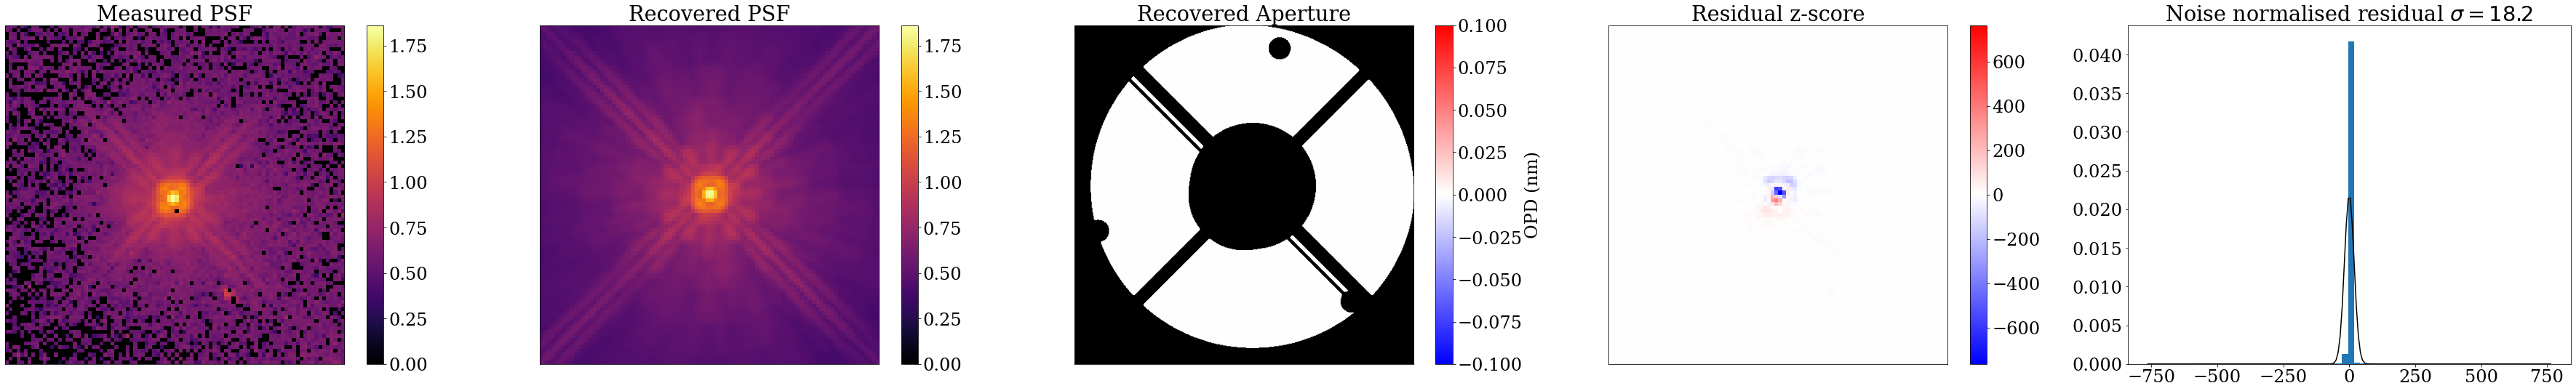

In [135]:
plot_comparison(model_single, params, exposures_single)

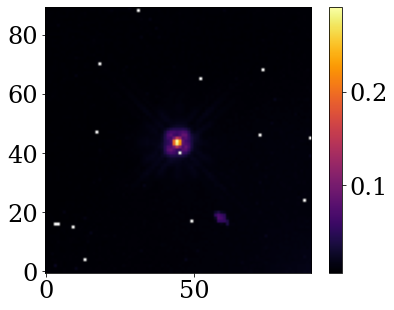

In [136]:
plt.imshow(exposures_single[0].err)
plt.colorbar()

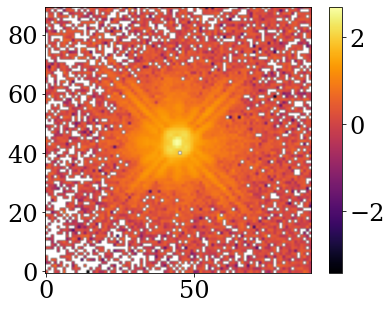

In [137]:
plt.imshow(np.log10(exposures_single[0].data/exposures_single[0].err))
plt.colorbar()

In [138]:
print(exposures_single[0].exptime)

319.9581


([], [])

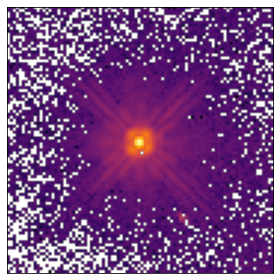

In [139]:
plt.imshow(exposures_single[0].data**0.125)
plt.xticks([])
plt.yticks([])

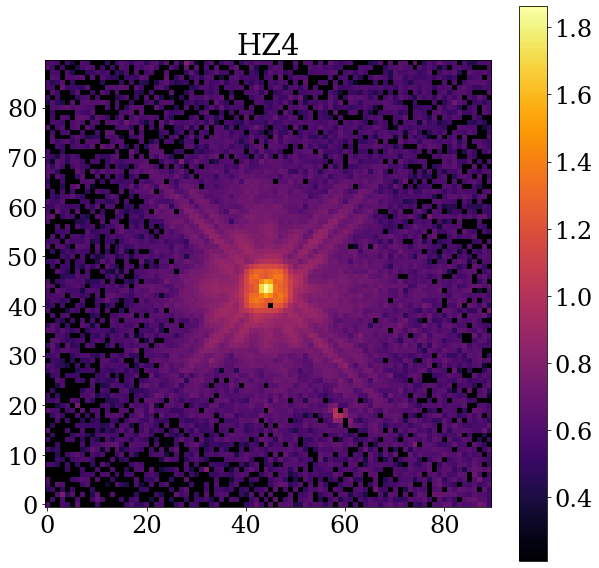

In [140]:
cmap = matplotlib.colormaps['inferno']
cmap.set_bad('k',1)
plt.figure(figsize=(10,10))
plt.imshow(exposures_single[0].data**0.125, cmap=cmap)
plt.title(exposures_single[0].target)
plt.colorbar()


In [141]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)

g = 5e-2

things = {
    "positions": sgd(g*2.5, 0),
    "spectrum": sgd(g*1.5, 10),
    "cold_mask_shift": sgd(g*0.5, 30),
    
    "bias": sgd(g*3, 20),
    "aberrations": sgd(g*2, 70),
    #"jitter": opt(g*1, 120),

    "despace": sgd(g*10, 50),
    "mag": sgd(g*3, 100),

    "cold_mask_shear": sgd(g*0.5, 100),
}

things_start = {
    "positions": sgd(g*5, 0),
}

groups = list(things.keys())

In [142]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [143]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 10)

[3.50030735e-07 2.95872351e-07]


  0%|          | 0/10 [00:00<?, ?it/s]

3.27140155760868


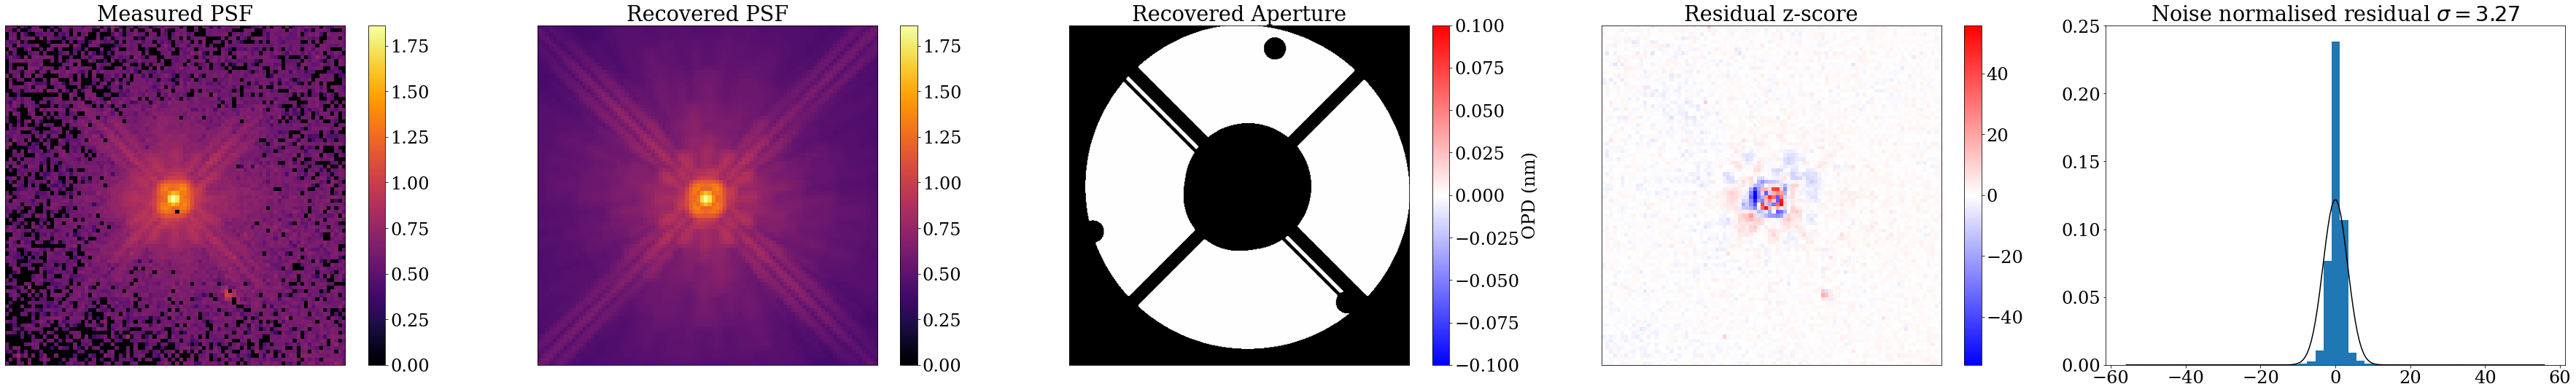

In [144]:
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

In [145]:
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [146]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things, 500, nbatches=5)

/Users/haydengreer/UQ/Subjects/Semester 2 2024/PHYS3900/hubble/.venv3/lib/python3.14/site-packages/jax/_src/interpreters/mlir.py:1164: UserWarning: A large amount of constants were captured during lowering (2.60GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)


[9.36680013e-01 7.59075998e-02 9.92712059e-03 1.12956786e-02
 6.73679812e-03 7.07938787e-03 5.40561350e-02 3.00346468e-02
 7.37816324e-02 4.86822829e-02 3.69984866e-02 1.68373474e-02
 1.58771909e-02 8.02845203e-03 7.75592556e-03 1.61355173e-02
 1.65625463e-02 7.36055430e-02 8.37704421e-02 3.76440530e-02
 1.24933992e-08 3.94851734e-03 3.31412262e-03 2.78465592e-03
 2.23033060e-03 1.73146005e-03 9.61904064e-07 5.32857000e-07
 5.80583191e-07 8.33562528e-08 6.86723851e-07 1.62528773e-06
 2.89364795e-06 5.58903789e-06]


  0%|          | 0/500 [00:00<?, ?it/s]

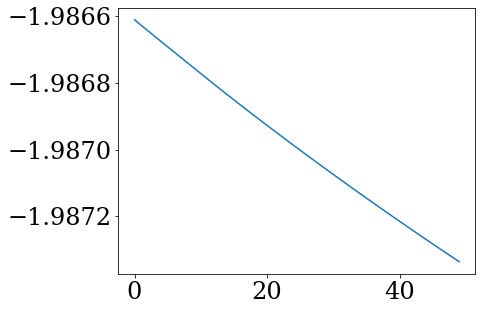

In [147]:
plt.plot(np.asarray(losses[-50:])/(len(exposures_single)*wid**2))

In [148]:
params_history_relative = [jax.tree.map(lambda x, y: x-y, x, params_history[0]) for x in params_history]

8
1.8087458761471404


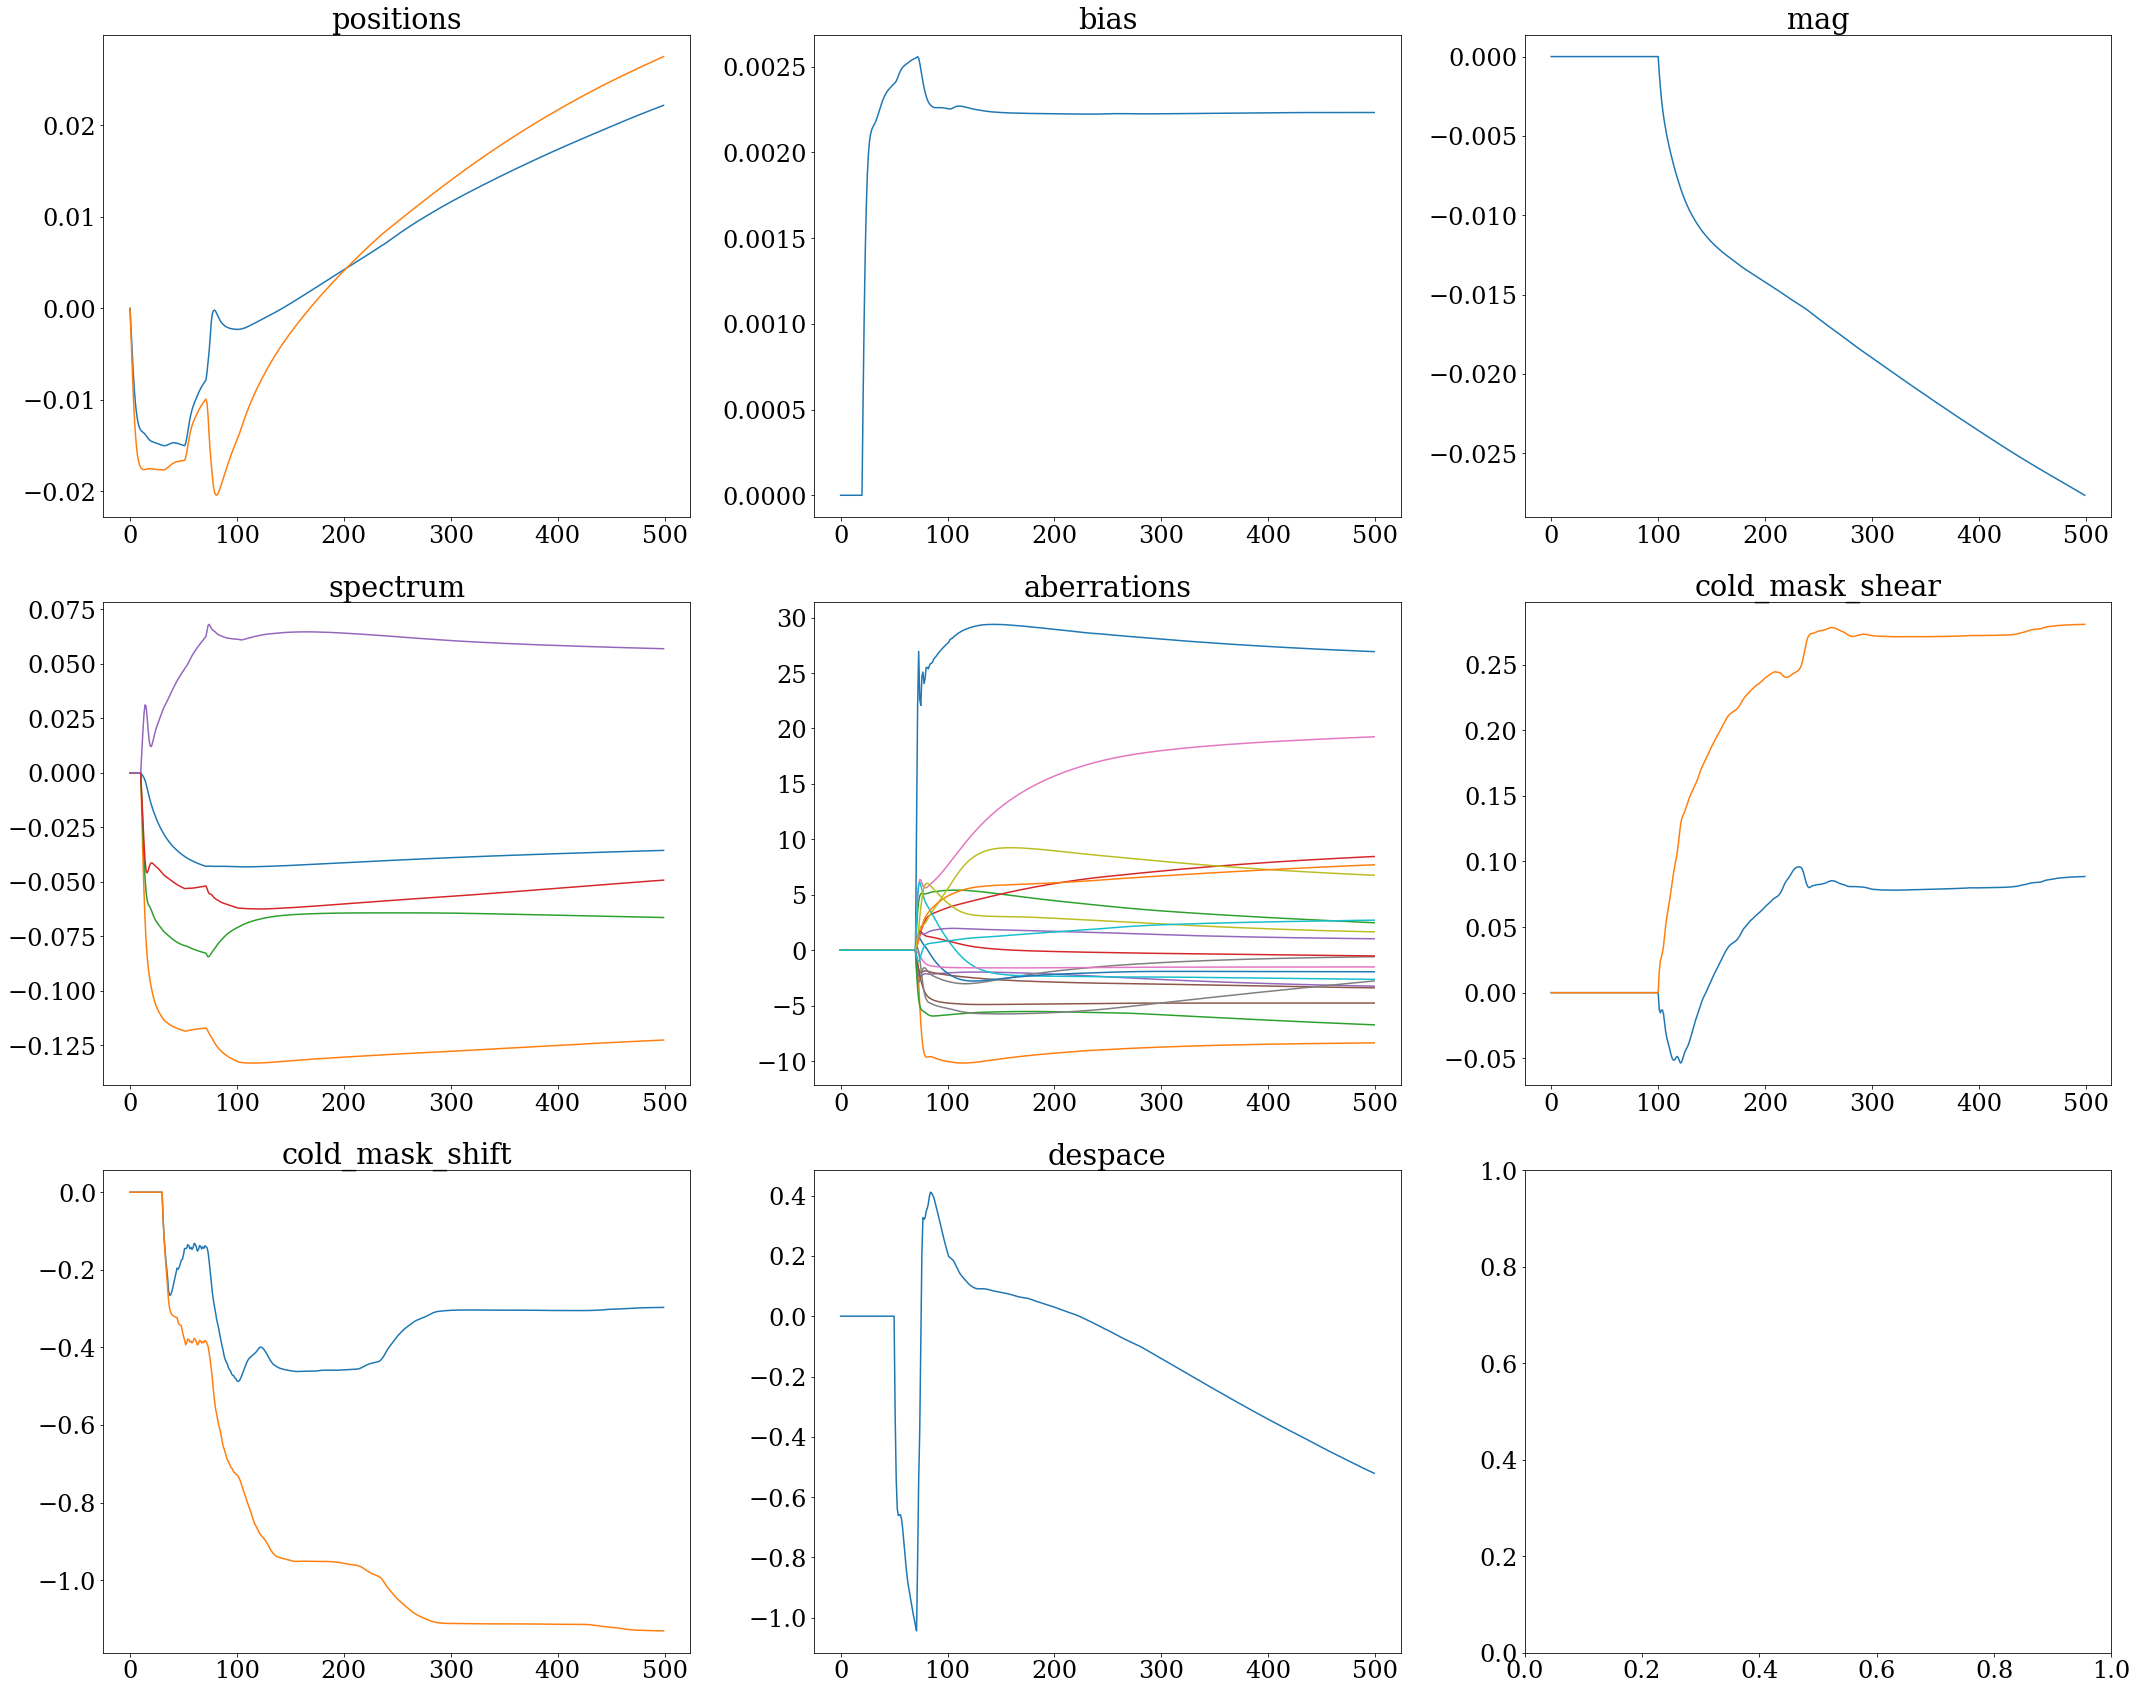

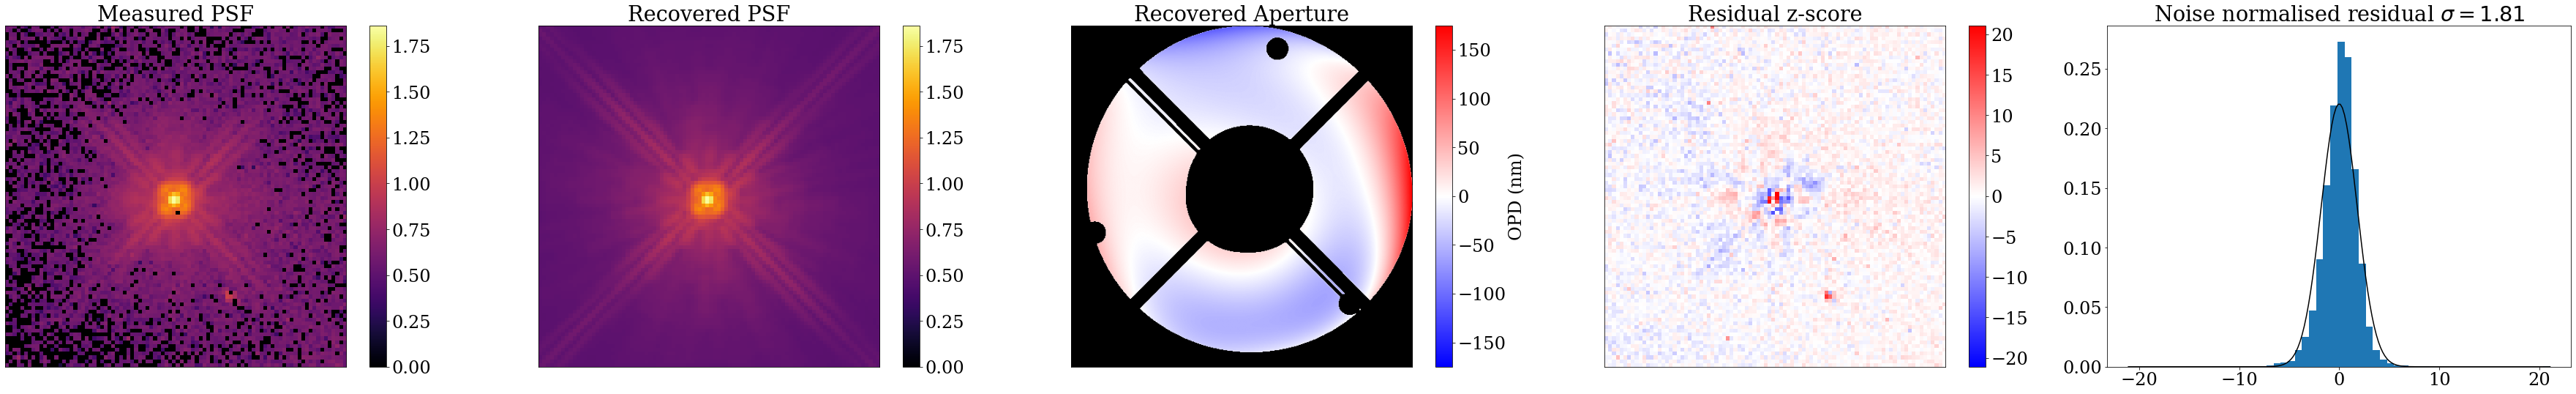

In [149]:
plot_params(params_history_relative, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

In [150]:
stop

NameError: name 'stop' is not defined

In [ ]:
final_params = optimise_optimistix(params_history[-1], model_single, exposures_single)

/Users/haydengreer/UQ/Subjects/Semester 2 2024/PHYS3900/hubble/.venv3/lib/python3.14/site-packages/jax/_src/interpreters/mlir.py:1164: UserWarning: A large amount of constants were captured during lowering (2.60GB total). If this is intentional, disable this warning by setting JAX_CAPTURED_CONSTANTS_WARN_BYTES=-1. To obtain a report of where these constants were encountered, set JAX_CAPTURED_CONSTANTS_REPORT_FRAMES=-1.
  warnings.warn(message)


KeyboardInterrupt: 

In [ ]:
final_params.params

{'aberrations': {'n8ry01tkq': Array([25.4786351 , -8.91333816, -0.11682813, 10.51163286, -3.23610107,
         -3.91899617, 20.37155396, -0.98868647,  5.31824913, -2.50543771,
         -1.82909743,  9.87892367, -9.46800286, -0.8751459 ,  1.12960406,
         -4.76092202, -1.47639871,  3.68765855,  1.59756902,  2.58580314],      dtype=float64)},
 'bias': {'n8ry01tkq': Array(0.0022041, dtype=float64)},
 'cold_mask_shear': {'global': Array([0.11053715, 0.27785803], dtype=float64)},
 'cold_mask_shift': {'global': Array([5.77193785, 4.81556139], dtype=float64)},
 'despace': {'n8ry01tkq': Array(-1.60357373, dtype=float64)},
 'mag': Array(3.25239214, dtype=float64),
 'positions': {'n8ry01tkq': Array([0.5482777 , 1.12961376], dtype=float64)},
 'spectrum': {'HZ4_F110W': Array([ 1.84048192, -0.10579477, -0.07088837,  0.03031192, -0.05073912],      dtype=float64)}}

In [ ]:
#sol.stats

1.8067330304577778


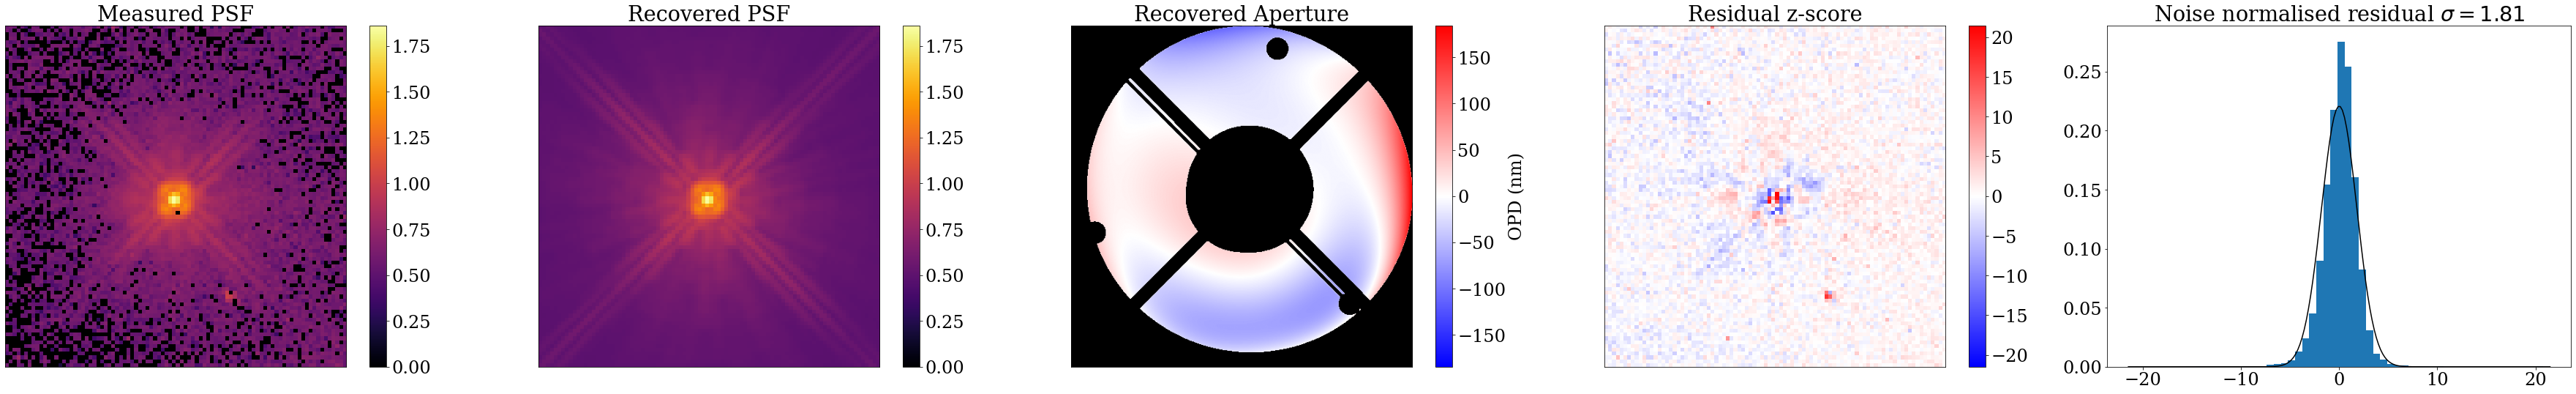

In [ ]:
plot_comparison(final_params.inject((model_single)), final_params, exposures_single)

In [ ]:
# calculate spectrum

In [ ]:
def loss_fn(params, exposures, model):
    mdl = params.inject(model)
    return np.nansum(np.asarray([posterior(mdl,exposure) for exposure in exposures]))


In [ ]:
f = lambda params: loss_fn(ModelParams(params), exposures_single, final_params.inject((model_single)))
F, unflatten = zdx.batching.hessian(f, {"spectrum":final_params["spectrum"]}, nbatches=2)

In [ ]:
cov_f110w = np.linalg.inv(F)#+fsh['n8yj02wyq.spectrum'])
spectrum_err = np.diag(np.sqrt(np.abs(cov_f110w)))


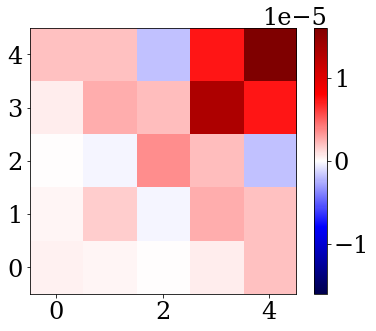

In [ ]:
plt.imshow(np.linalg.inv(F), cmap='seismic', vmin=-np.max(np.abs(cov_f110w)), vmax=np.max(np.abs(cov_f110w)))
plt.colorbar()


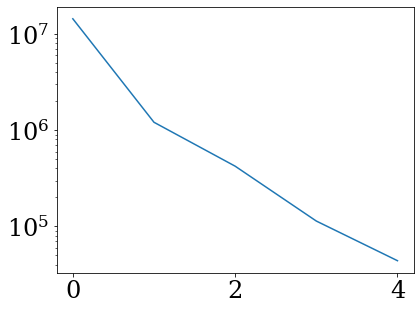

In [ ]:
vals, vects = np.linalg.eig(F)#+fsh['n8yj02wyq.spectrum'])

order = np.argsort(vals)[::-1]

#plt.figure(figsize=(10,10))
#plt.xlabel("Coefficient")

#for i in range(5):
#    plt.plot(np.arange(npoly),np.real(vects[:,order[i]]), label=f"{i}")
#plt.legend()

plt.semilogy(np.sort(np.real(vals))[::-1])

In [ ]:
#spec.filt_weights.sum()
#spec2.filt_weights.sum()

In [ ]:
#(filt/(wv*1e6)).sum()/(filt2/(wv*1e6)).sum()

Text(0.5, 0, 'Wavelength (um)')

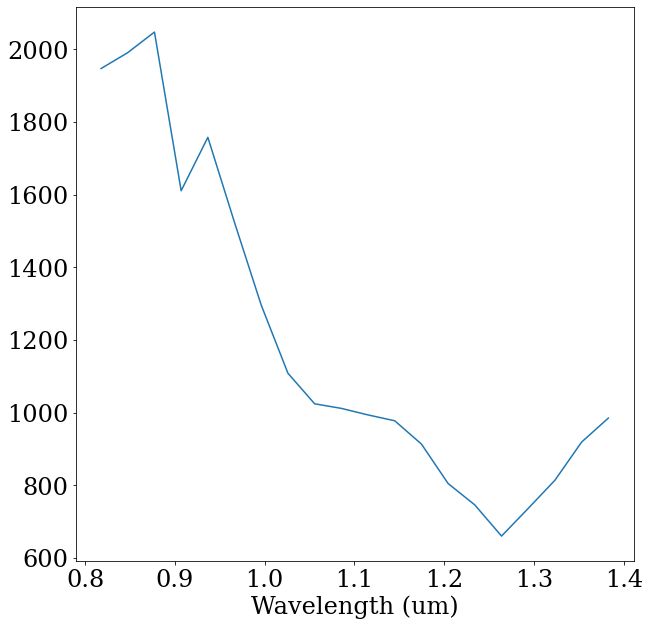

In [ ]:
plt.figure(figsize=(10,10))

wv, filt = calc_throughput("F110W", nwavels=nwavels)

spec = CombinedBasisSpectrum(wv, filt, final_params.get("spectrum.HZ4_F110W"), spectrum_basis_f110w)

# wv2, filt2 = calc_throughput("F160W", nwavels=nwavels)

# spec2 = CombinedBasisSpectrum(wv2, filt2, final_params.get("spectrum.HZ4_F160W"), spectrum_basis)


sp = spec.spec_weights()/spec.flux*spec.proper_flux()#/(wv*1e6)
# sp2 = spec2.spec_weights()/spec2.flux*spec2.proper_flux()#/(wv2*1e6)

#plt.plot(wavels, params.get("spectrum.U10764_F110W"))
plt.plot(wv*1e6, sp)
# plt.plot(wv2*1e6, sp2)

plt.xlabel("Wavelength (um)")


In [ ]:
from scipy.optimize import curve_fit
from scipy.constants import h, c, k

def planck_wavelength(wav, T, scale, bg):
    """
    Planck's Law as a function of wavelength (m) and temperature (K).
    Returns intensity in arbitrary units with a scaling factor.
    """
    a = 2.0 * h * c**2
    b = h * c / (wav * k * T)
    intensity = scale * a / ( (wav**4) * (np.exp(b) - 1.0) ) + bg# * (wav/1e-6)
    return intensity

def rayleigh_jeans(wav, scale):#, bg):
    return scale/wav**4# + bg

In [ ]:
wavels = np.concat((wv, wv2))
spectrum = np.concat((sp, sp2))

initial_guesses = [14500.0, 1e-12, 0.] 

# Perform the curve fit
popt, pcov = curve_fit(planck_wavelength, wavels, spectrum, p0=initial_guesses, maxfev=10000)
print(popt)


NameError: name 'wv2' is not defined

In [ ]:
from jax.numpy import linalg as la
def nearestPD(A):
    """Find the nearest positive-definite matrix to input

    A Python/Numpy port of John D'Errico's `nearestSPD` MATLAB code [1], which
    credits [2].

    [1] https://www.mathworks.com/matlabcentral/fileexchange/42885-nearestspd

    [2] N.J. Higham, "Computing a nearest symmetric positive semidefinite
    matrix" (1988): https://doi.org/10.1016/0024-3795(88)90223-6
    """

    B = (A + A.T) / 2
    _, s, V = la.svd(B)

    H = np.dot(V.T, np.dot(np.diag(s), V))

    A2 = (B + H) / 2

    A3 = (A2 + A2.T) / 2

    if isPD(A3):
        return A3

    spacing = np.spacing(la.norm(A))
    # The above is different from [1]. It appears that MATLAB's `chol` Cholesky
    # decomposition will accept matrixes with exactly 0-eigenvalue, whereas
    # Numpy's will not. So where [1] uses `eps(mineig)` (where `eps` is Matlab
    # for `np.spacing`), we use the above definition. CAVEAT: our `spacing`
    # will be much larger than [1]'s `eps(mineig)`, since `mineig` is usually on
    # the order of 1e-16, and `eps(1e-16)` is on the order of 1e-34, whereas
    # `spacing` will, for Gaussian random matrixes of small dimension, be on
    # othe order of 1e-16. In practice, both ways converge, as the unit test
    # below suggests.
    I = np.eye(A.shape[0])
    k = 1
    while not isPD(A3):
        mineig = np.min(np.real(la.eigvals(A3)))
        A3 += I * (-mineig * k**2 + spacing)
        k += 1

    return A3


def isPD(B):
    """Returns true when input is positive-definite, via Cholesky"""
    try:
        _ = la.cholesky(B)
        return True
    except la.LinAlgError:
        return False


In [ ]:
popt

array([4.89643498e+07, 1.24228375e-09, 9.71740101e+01])

In [ ]:
np.sqrt(pcov[0,0])

Array(4.9985071e+10, dtype=float64)

In [ ]:
np.round(153.2, -2)

Array(200., dtype=float64, weak_type=True)

In [ ]:
spectrum

Array([1218.69963483, 1108.36854104,  866.75038007,  859.74498962,
        645.98003809,  747.40052724,  753.50013642,  668.5838694 ,
        601.13530482,  554.57669037,  516.71959613,  542.66214504,
        512.71780501,  461.10071388,  433.64046184,  435.51881131,
        394.18225732,  390.57450244,  368.81976617,  373.36558903,
        349.64249899,  347.30413676,  334.1530475 ,  305.58306284,
        324.40802796,  320.45150246,  262.0745529 ,  301.90218475,
        402.11730558,  296.38346693,  214.88859025,  416.89536238,
        334.86041236,  348.89829475,  315.48393068,  287.22727938,
        291.70468118,  275.15213298,  259.83366664,  257.86365221,
        238.37869283,  242.54613484,  234.32684598,  213.70810888,
        228.32362697,  243.32795574,  238.43095511,  226.42660366,
        218.35424721,  217.73337751,  206.19838686,  205.44867872,
        194.32068281,  185.29611256,  187.58926727,  171.54054755,
        129.74353891,  150.79322897,  214.6386563 ,  168.60190

In [ ]:
planck_wavelength(wavels, *popt) - spectrum #+ popt[2]

Array([-184.32713116, -139.32132407,   42.90432077,   -4.20832169,
        160.13983239,   13.50456299,  -34.04505473,   12.80180404,
         45.22384266,   59.50133806,   67.55816822,   14.06290481,
         18.493862  ,   46.45184518,   51.94175935,   29.63376994,
         51.94871796,   37.82346448,   43.02679014,   23.01418542,
         32.2676387 ,   21.05472537,   21.50082795,   38.1473055 ,
          8.12107901,    1.54464791,   50.00791254,    0.8409788 ,
       -108.17997101,  -10.75617315,   67.85535868, -139.81417443,
        -63.21396514,  -82.46983523,  -54.06746815,  -30.62682428,
        -39.733792  ,  -27.63329023,  -16.59775377,  -18.74952123,
         -3.23274624,  -11.2217938 ,   -6.68427494,   10.38622676,
         -7.65006383,  -25.95326421,  -24.23877032,  -15.30551   ,
        -10.19771412,  -12.43946924,   -3.66948855,   -5.59129484,
          2.95475631,    9.48320025,    4.77622886,   18.49010273,
         58.02796629,   34.79182665,  -31.17024159,   12.81694

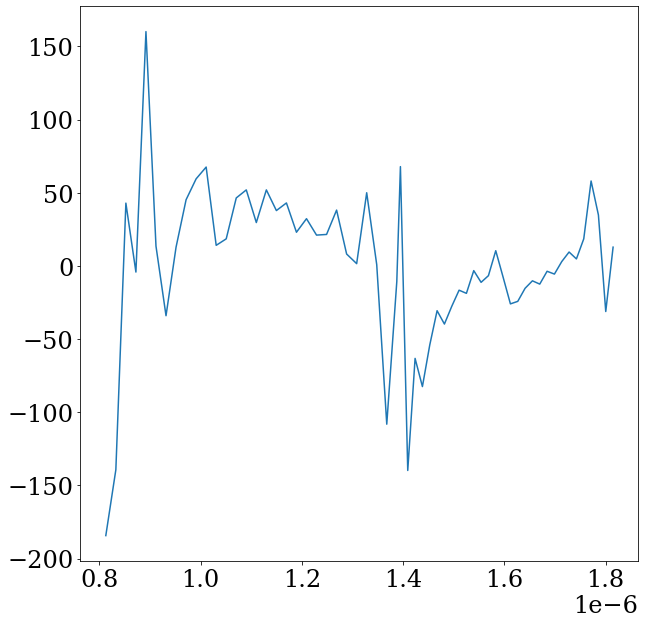

In [ ]:
plt.figure(figsize=(10,10))
plt.plot(wavels, planck_wavelength(wavels, *popt) - spectrum)#+  popt[2])

Text(0.5, 0, 'Wavelength (um)')

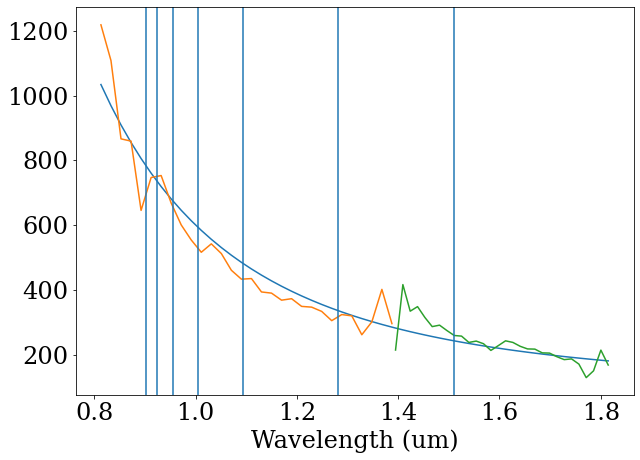

In [ ]:
plt.figure(figsize=(10,7))

plt.plot(np.sort(wavels)*1e6, planck_wavelength(np.sort(wavels), *popt), label=fr"Blackbody Curve")# $T = {np.round(popt[0], -3):3.0f}$")
plt.plot(wv*1e6, sp, label = "F110W Spectrum")
plt.plot(wv2*1e6, sp2, label = "F160W Spectrum")

plt.axvline(1.282)
plt.axvline(1.094)
plt.axvline(0.9546)
plt.axvline(1.005)
plt.axvline(0.923)
plt.axvline(0.901)

plt.axvline(1.51)



plt.xlabel("Wavelength (um)")
#plt.legend()

Text(0.5, 0, 'Wavelength (um)')

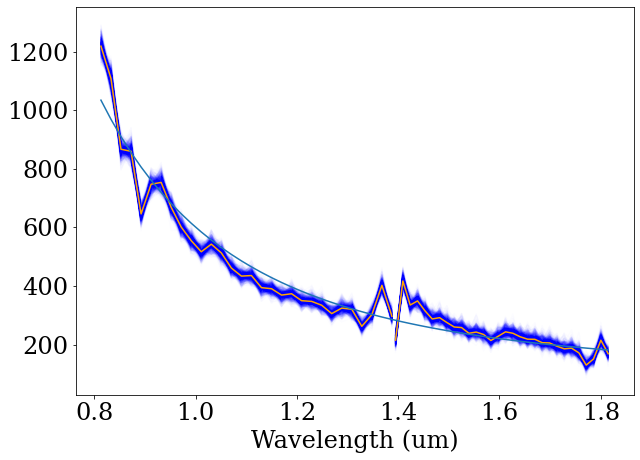

In [ ]:
plt.figure(figsize=(10,7))

plt.plot(wv*1e6, sp, color='orange')
plt.plot(wv2*1e6, sp2, color='orange')

for i in range(1000):
    coeffs = numpy.random.multivariate_normal(final_params.get("spectrum.HZ4_F110W"), nearestPD(cov_f110w))
    spec = CombinedBasisSpectrum(wv, filt, coeffs, spectrum_basis)#CombinedFourierSpectrum(wv, filt, coeffs)
    plt.plot(wv*1e6, spec.spec_weights()/spec.flux*spec.proper_flux()/(wv*1e6), color='b', alpha=0.01, zorder=0)

for i in range(1000):
    coeffs = numpy.random.multivariate_normal(final_params.get("spectrum.HZ4_F160W"), nearestPD(cov_f160w))
    spec = CombinedBasisSpectrum(wv2, filt2, coeffs, spectrum_basis)#CombinedFourierSpectrum(wv, filt, coeffs)
    plt.plot(wv2*1e6, spec.spec_weights()/spec.flux*spec.proper_flux()/(wv2*1e6), color='b', alpha=0.01, zorder=0)

plt.plot(wavels*1e6, planck_wavelength(wavels, *popt), label=fr"Blackbody Curve")# $T = {np.round(popt[0], -3):3.0f}$")


plt.xlabel("Wavelength (um)")
#plt.legend()

Text(0.5, 0, 'Wavelength (um)')

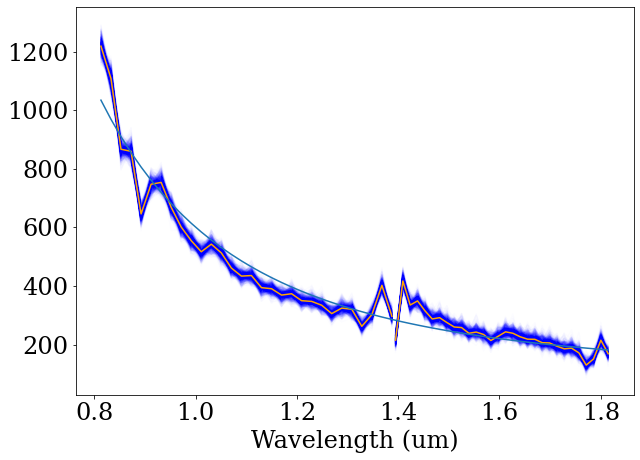

In [ ]:
plt.figure(figsize=(10,7))

plt.plot(wv*1e6, sp, color='orange')
plt.plot(wv2*1e6, sp2, color='orange')

for i in range(1000):
    coeffs = numpy.random.multivariate_normal(final_params.get("spectrum.HZ4_F110W"), nearestPD(cov_f110w))
    spec = CombinedBasisSpectrum(wv, filt, coeffs, spectrum_basis)#CombinedFourierSpectrum(wv, filt, coeffs)
    plt.plot(wv*1e6, spec.spec_weights()/spec.flux*spec.proper_flux()/(wv*1e6), color='b', alpha=0.01, zorder=0)

for i in range(1000):
    coeffs = numpy.random.multivariate_normal(final_params.get("spectrum.HZ4_F160W"), nearestPD(cov_f160w))
    spec = CombinedBasisSpectrum(wv2, filt2, coeffs, spectrum_basis)#CombinedFourierSpectrum(wv, filt, coeffs)
    plt.plot(wv2*1e6, spec.spec_weights()/spec.flux*spec.proper_flux()/(wv2*1e6), color='b', alpha=0.01, zorder=0)

plt.plot(wavels*1e6, planck_wavelength(wavels, *popt), label=fr"Blackbody Curve")# $T = {np.round(popt[0], -3):3.0f}$")


plt.xlabel("Wavelength (um)")
#plt.legend()